In [40]:
import numpy as np
sims = 1000000

A = np.random.uniform(1,5,sims)
B = np.random.uniform(2,6,sims)

duration = A + B

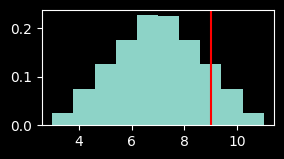

0.125013


In [41]:
import matplotlib.pyplot as plt
# Matplotlib darkmode
plt.style.use('dark_background')

plt.figure(figsize= (3,1.5))
plt.hist(duration, density=True)
plt.axvline(9, color='r')
plt.show()
print((duration>9).sum()/sims)

In [42]:
import pandas as pd

data = []

df = pd.DataFrame(data)

In [43]:
if len(df) > 0: 
    print("yes")

In [44]:
df_rentals = pd.read_parquet("../data/3_gold_analytics/market_overview_rent.parquet")
df_sales = pd.read_parquet("../data/3_gold_analytics/market_overview_sale.parquet")

In [45]:
df_rentals

,munis,city,suburb,total_listings,median_price,avg_price_per_m2,solar_penetration,estate_percentage,resilience_score
0,City of Johannesburg,bedfordview,bedford gardens,79,15000.0,262.251190,0.0,0.012658,0.0
1,City of Johannesburg,bedfordview,bedford park,2,34950.0,580.420710,0.0,0.000000,0.0
2,City of Johannesburg,bedfordview,bedfordview,189,12899.5,403.201456,0.0,0.116402,0.0
3,City of Johannesburg,bedfordview,essexwold,2,11500.0,89.588231,0.0,0.000000,0.0
4,City of Johannesburg,bedfordview,morning hill,10,12500.0,107.233005,0.0,0.000000,0.0
...,...,...,...,...,...,...,...,...,...
1110,West Rand,randfontein,vleikop ah,4,6600.0,72.807015,0.0,0.000000,0.0
1111,West Rand,randfontein,west porges,1,5500.0,24.549385,0.0,0.000000,0.0
1112,West Rand,randfontein,westergloor,1,8000.0,35.139353,0.0,0.000000,0.0
1113,West Rand,westonaria,westonaria,5,6445.0,113.744292,0.0,0.200000,0.0


In [46]:
df_sales

,munis,city,suburb,total_listings,median_price,avg_price_per_m2,solar_penetration,estate_percentage,resilience_score
0,City of Johannesburg,bedfordview,bedford gardens,272,1040000.0,11247.502687,0.000000,0.011029,0.0
1,City of Johannesburg,bedfordview,bedford park,37,3250000.0,10564.332086,0.000000,0.027027,0.0
2,City of Johannesburg,bedfordview,bedfordview,645,3495000.0,34168.813834,0.006202,0.068217,0.1
3,City of Johannesburg,bedfordview,essexwold,11,3400000.0,12537.625680,0.000000,0.000000,0.0
4,City of Johannesburg,bedfordview,morning hill,30,2750000.0,9532.734055,0.000000,0.033333,0.0
...,...,...,...,...,...,...,...,...,...
1594,West Rand,westonaria,venterspos,17,550000.0,2804.181160,0.000000,0.000000,0.0
1595,West Rand,westonaria,west rand ah,4,1086000.0,5479.341683,0.000000,0.000000,0.0
1596,West Rand,westonaria,westonaria,158,850000.0,6358.831624,0.000000,0.018987,0.0
1597,West Rand,westonaria,westonaria rural,5,725000.0,12824.773156,0.000000,0.000000,0.0


In [47]:
df_rentals['location'] = (
    df_rentals['suburb'].str.lower().str.replace(' ', '_') + 
    '_' + 
    df_rentals['city'].str.lower().str.replace(' ', '_')
)
df_sales['location'] = (
    df_sales['suburb'].str.lower().str.replace(' ', '_') + 
    '_' + 
    df_sales['city'].str.lower().str.replace(' ', '_')
)

In [48]:
df_ration = df_rentals.merge(
    df_sales,
    how='outer',
    on='location'
)

In [49]:
df_ration = df_ration[['location', 'total_listings_x', 'total_listings_y']]

In [50]:
df = df_ration.rename(columns={'total_listings_x':'total_rentals','total_listings_y':'total_sales'})

In [51]:
df['ratio'] = df['total_rentals']/df['total_sales']

In [52]:
df

,location,total_rentals,total_sales,ratio
0,a_p_khumalo_katlehong,NaN,3.0,NaN
1,abbotsford_johannesburg,1.0,11.0,0.090909
2,activia_park_germiston,NaN,1.0,NaN
3,actonville_benoni,4.0,65.0,0.061538
4,admin_katlehong,1.0,NaN,NaN
...,...,...,...,...
1637,zwartkop_centurion,21.0,106.0,0.198113
1638,zwartkop_golf_estate_centurion,NaN,24.0,NaN
1639,zwartkoppies_pretoria,4.0,25.0,0.160000
1640,zwartkops_krugersdorp,NaN,1.0,NaN


In [53]:
sales = pd.read_parquet('../data/3_gold_analytics/yield_overview.parquet')

In [54]:
sales

,listing_number,scrape_at,price,title,type,suburb,city,munis,bedrooms,bathrooms,parking,floor_size,is_estate,has_security,is_modern,location,total_rooms,suburb_avg_rent,predicted_rent,predicted_gross_yield
0,116765224,2026-02-17 15:55:49.813540,1199000.0,3 Bedroom House,House,andeon,pretoria,City of Tshwane,3.0,2.0,1.0,250.0,0,1,0,andeon_pretoria,5.0,8128.500000,8691.266667,8.698515
1,113673966,2026-02-17 15:55:49.812897,1480000.0,4 Bedroom House,House,andeon,pretoria,City of Tshwane,4.0,2.5,2.0,241.0,0,0,0,andeon_pretoria,6.5,8128.500000,11876.625000,9.629696
2,114071645,2026-02-17 15:55:49.812278,1290000.0,3 Bedroom House,House,andeon,pretoria,City of Tshwane,3.0,3.0,2.0,235.0,0,0,0,andeon_pretoria,6.0,8128.500000,12879.730714,11.981145
3,115988759,2026-02-17 15:55:49.811620,1199000.0,3 Bedroom House,House,andeon,pretoria,City of Tshwane,3.0,2.0,1.0,250.0,0,1,0,andeon_pretoria,5.0,8128.500000,8691.266667,8.698515
4,116373495,2026-02-17 15:55:42.011576,695000.0,2 Bedroom Townhouse,Townhouse,andeon,pretoria,City of Tshwane,2.0,1.0,0.0,77.0,0,0,0,andeon_pretoria,3.0,8128.500000,6845.440000,11.819465
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93022,116897648,2026-02-15 23:52:09.817877,1950000.0,4 Bedroom House,House,amandasig,akasia,City of Tshwane,4.0,3.0,4.0,300.0,0,0,0,amandasig_akasia,7.0,13014.230769,16869.350000,10.381138
93023,116902269,2026-02-15 23:52:09.816917,849000.0,2 Bedroom Townhouse,Townhouse,amandasig,akasia,City of Tshwane,2.0,2.0,2.0,1.0,0,0,0,amandasig_akasia,4.0,13014.230769,11737.032333,16.589445
93024,116844625,2026-02-15 23:52:09.815620,2900000.0,5 Bedroom House,House,amandasig,akasia,City of Tshwane,5.0,3.0,3.0,620.0,1,1,1,amandasig_akasia,8.0,13014.230769,27020.740000,11.180996
93025,116903385,2026-02-15 23:52:09.814919,1990000.0,3 Bedroom House,House,amandasig,akasia,City of Tshwane,3.0,3.0,4.0,1029.0,0,0,1,amandasig_akasia,6.0,13014.230769,22190.650000,13.381296


In [55]:
sales['price'].describe()

count    9.250500e+04
mean     1.902710e+06
std      6.098823e+06
min      4.600000e+02
25%      7.350000e+05
50%      1.100000e+06
75%      1.949000e+06
max      1.250000e+09
Name: price, dtype: float64

In [56]:
sales = sales.dropna(subset=['price'])

In [57]:
sales.sort_values('price').tail(40)

,listing_number,scrape_at,price,title,type,suburb,city,munis,bedrooms,bathrooms,parking,floor_size,is_estate,has_security,is_modern,location,total_rooms,suburb_avg_rent,predicted_rent,predicted_gross_yield
20488,112531159,2026-02-16 21:08:47.688822,4.800000e+07,5 Bedroom House,House,bryanston,sandton,City of Johannesburg,5.0,5.0,5.0,7177.0,0,1,0,bryanston_sandton,10.0,27389.779783,75411.333333,1.885283
22124,116063090,2026-02-16 20:49:25.256024,4.800000e+07,6 Bedroom House,House,atholl,sandton,City of Johannesburg,6.0,7.0,3.0,2500.0,0,1,0,atholl_sandton,13.0,25526.190476,72857.000000,1.821425
45924,112958711,2026-02-16 14:30:24.232024,4.800000e+07,20 Bedroom House,House,baileys muckleneuk,pretoria,City of Tshwane,20.0,20.0,13.0,2552.0,0,0,0,baileys_muckleneuk_pretoria,40.0,16662.294118,36629.350000,0.915734
15297,116757788,2026-02-16 22:24:45.496716,4.900000e+07,5 Bedroom House,House,sandhurst,sandton,City of Johannesburg,5.0,5.5,20.0,2011.0,0,0,0,sandhurst_sandton,10.5,32277.894737,79747.995000,1.953012
47432,115690894,2026-02-16 13:59:21.494550,4.999990e+07,6 Bedroom Apartment,Apartment,waterfall,midrand,City of Johannesburg,6.0,6.0,5.0,1230.0,0,0,0,waterfall_midrand,12.0,19487.656085,53348.230000,1.280360
47531,115854161,2026-02-16 13:58:39.462404,5.299990e+07,6 Bedroom Apartment,Apartment,waterfall,midrand,City of Johannesburg,6.0,6.0,5.0,1230.0,0,0,0,waterfall_midrand,12.0,19487.656085,53348.230000,1.207887
48396,116555173,2026-02-16 12:53:00.217792,5.300000e+07,6 Bedroom House,House,steyn city,midrand,City of Johannesburg,6.0,6.5,15.0,1865.0,0,0,0,steyn_city_midrand,12.5,40480.714286,79932.495000,1.809792
48383,116211284,2026-02-16 12:53:08.919035,5.300000e+07,6 Bedroom House,House,steyn city,midrand,City of Johannesburg,6.0,6.5,17.0,2209.0,0,0,0,steyn_city_midrand,12.5,40480.714286,76213.500000,1.725589
47467,115600172,2026-02-16 13:59:04.742906,5.450000e+07,4 Bedroom House,House,waterfall,midrand,City of Johannesburg,4.0,4.5,8.0,9408.0,1,1,0,waterfall_midrand,8.5,19487.656085,59716.500000,1.314859
80305,116625691,2026-02-16 02:51:36.562788,5.500000e+07,110 Bedroom House,House,witfield,boksburg,Ekurhuleni,110.0,110.0,110.0,5000.0,0,0,0,witfield_boksburg,220.0,7599.193548,30217.500000,0.659291


In [58]:
sales.sort_values('predicted_gross_yield')['predicted_gross_yield'].head()

2584     0.014781
36494    0.014970
77651    0.072818
64070    0.101175
30437    0.130134
Name: predicted_gross_yield, dtype: float64

In [59]:
sales = sales[(sales['price'] > 100000) & (sales['price'] < 15000000)]

In [60]:
df = pd.read_parquet('../data/4_feature_store/rental_features.parquet')

In [61]:
df

,bedrooms,bathrooms,parking,floor_size,suburb_avg_rent,is_estate,has_security,is_modern,type,price
0,1.0,1.0,4.0,46.0,8128.500000,0,0,1,Apartment,6250.0
1,2.0,1.0,4.0,46.0,8128.500000,0,0,0,Apartment,7350.0
2,2.0,1.0,3.0,64.0,8128.500000,0,0,0,Apartment,7350.0
3,3.0,3.0,2.0,300.0,8128.500000,1,1,0,House,13000.0
4,3.0,2.0,2.0,270.0,8128.500000,1,1,0,House,8000.0
...,...,...,...,...,...,...,...,...,...,...
18187,3.0,3.0,4.0,500.0,13014.230769,1,1,1,House,15000.0
18188,3.0,2.5,3.0,300.0,13014.230769,0,0,0,Townhouse,9400.0
18189,5.0,4.0,2.0,300.0,13014.230769,0,0,0,House,17070.0
18190,3.0,2.0,4.0,300.0,13014.230769,1,1,0,House,11000.0


In [62]:
sub = pd.read_parquet('../data/4_feature_store/suburb_rent_stats.parquet')

In [63]:
sub

,location,suburb_avg_rent
0,abbotsford_johannesburg,30000.000000
1,actonville_benoni,6000.000000
2,admin_katlehong,6000.000000
3,aeroton_johannesburg,6460.000000
4,agavia_krugersdorp,9231.250000
...,...,...
1102,zandspruit_roodepoort,19325.000000
1103,zola_soweto,9066.666667
1104,zwartkop_centurion,10351.750000
1105,zwartkoppies_pretoria,11250.000000


In [64]:
loc = pd.read_parquet('../data/0_metadata/suburb_lookup.parquet')

In [65]:
loc

,suburb_id,suburb_name,city_id,city_name,province_id,province_name,municipality,last_scraped
0,3990,amandasig,2462,akasia,1,gauteng,City of Tshwane,2026-02-15
1,4002,chantelle,2462,akasia,1,gauteng,City of Tshwane,2026-02-15
2,4012,clarina,2462,akasia,1,gauteng,City of Tshwane,2026-02-15
3,4102,doreg ah,2462,akasia,1,gauteng,City of Tshwane,2026-02-15
4,429,eldorette,2462,akasia,1,gauteng,City of Tshwane,2026-02-15
...,...,...,...,...,...,...,...,...
2068,346,rooiwal ah,2473,wonderboom,1,gauteng,City of Tshwane,2026-02-17
2069,347,vasfontein ah,2473,wonderboom,1,gauteng,City of Tshwane,2026-02-17
2070,17,walmansthal ah,2473,wonderboom,1,gauteng,City of Tshwane,2026-02-17
2071,55,waterval ah,2473,wonderboom,1,gauteng,City of Tshwane,2026-02-18


In [66]:
loc['city_id'].nunique()

43

In [67]:
df_rentals

,munis,city,suburb,total_listings,median_price,avg_price_per_m2,solar_penetration,estate_percentage,resilience_score,location
0,City of Johannesburg,bedfordview,bedford gardens,79,15000.0,262.251190,0.0,0.012658,0.0,bedford_gardens_bedfordview
1,City of Johannesburg,bedfordview,bedford park,2,34950.0,580.420710,0.0,0.000000,0.0,bedford_park_bedfordview
2,City of Johannesburg,bedfordview,bedfordview,189,12899.5,403.201456,0.0,0.116402,0.0,bedfordview_bedfordview
3,City of Johannesburg,bedfordview,essexwold,2,11500.0,89.588231,0.0,0.000000,0.0,essexwold_bedfordview
4,City of Johannesburg,bedfordview,morning hill,10,12500.0,107.233005,0.0,0.000000,0.0,morning_hill_bedfordview
...,...,...,...,...,...,...,...,...,...,...
1110,West Rand,randfontein,vleikop ah,4,6600.0,72.807015,0.0,0.000000,0.0,vleikop_ah_randfontein
1111,West Rand,randfontein,west porges,1,5500.0,24.549385,0.0,0.000000,0.0,west_porges_randfontein
1112,West Rand,randfontein,westergloor,1,8000.0,35.139353,0.0,0.000000,0.0,westergloor_randfontein
1113,West Rand,westonaria,westonaria,5,6445.0,113.744292,0.0,0.200000,0.0,westonaria_westonaria


In [68]:
import glob


path = f"../data/2_silver_cleaned/type=sale/listings.parquet"
files = glob.glob(path)

# concat all
df = pd.concat([pd.read_parquet(f) for f in files])

In [69]:
df

,listing_number,scrape_at,price,title,type,suburb,city,munis,bedrooms,bathrooms,...,floor_size,is_estate,has_security,is_modern,last_seen,location,total_rooms,price_sqm,z_score,suburb_avg_rent
0,116923682,2026-02-18T05:35:18.372638,1480000.0,4 Bedroom House,House,andeon,pretoria,city of tshwane,4.0,2.5,...,241.0,0,0,0,2026-02-18 05:35:18.372638,andeon_pretoria,6.5,6141.078838,-0.187469,7867.619048
1,113673966,2026-02-18T05:35:18.371980,1480000.0,4 Bedroom House,House,andeon,pretoria,city of tshwane,4.0,2.5,...,241.0,0,0,0,2026-02-18 05:35:18.371980,andeon_pretoria,6.5,6141.078838,-0.187469,7867.619048
2,114071645,2026-02-18T05:35:18.371348,1290000.0,3 Bedroom House,House,andeon,pretoria,city of tshwane,3.0,3.0,...,235.0,0,0,0,2026-02-18 05:35:18.371348,andeon_pretoria,6.0,5489.361702,-0.192584,7867.619048
3,115988759,2026-02-18T05:35:18.370704,1199000.0,3 Bedroom House,House,andeon,pretoria,city of tshwane,3.0,2.0,...,250.0,0,1,0,2026-02-18 05:35:18.370704,andeon_pretoria,5.0,4796.000000,-0.198026,7867.619048
4,116373495,2026-02-18T05:35:10.486258,695000.0,2 Bedroom Townhouse,Townhouse,andeon,pretoria,city of tshwane,2.0,1.0,...,77.0,0,0,0,2026-02-18 05:35:10.486258,andeon_pretoria,3.0,9025.974026,-0.164827,7867.619048
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90853,116908126,2026-02-15T23:52:09.818718,2150000.0,4 Bedroom House,House,amandasig,akasia,city of tshwane,4.0,2.5,...,402.0,0,0,0,2026-02-15 23:52:09.818718,amandasig_akasia,6.5,5348.258706,-0.082576,13224.800000
90854,116897648,2026-02-15T23:52:09.817877,1950000.0,4 Bedroom House,House,amandasig,akasia,city of tshwane,4.0,3.0,...,300.0,0,0,0,2026-02-15 23:52:09.817877,amandasig_akasia,7.0,6500.000000,-0.074576,13224.800000
90855,116844625,2026-02-15T23:52:09.815620,2900000.0,5 Bedroom House,House,amandasig,akasia,city of tshwane,5.0,3.0,...,620.0,1,1,1,2026-02-15 23:52:09.815620,amandasig_akasia,8.0,4677.419355,-0.087235,13224.800000
90856,116903385,2026-02-15T23:52:09.814919,1990000.0,3 Bedroom House,House,amandasig,akasia,city of tshwane,3.0,3.0,...,1029.0,0,0,1,2026-02-15 23:52:09.814919,amandasig_akasia,6.0,1933.916424,-0.106292,13224.800000


In [70]:
df[df['price']>10000000].sort_values('price', ascending=False)

,listing_number,scrape_at,price,title,type,suburb,city,munis,bedrooms,bathrooms,...,floor_size,is_estate,has_security,is_modern,last_seen,location,total_rooms,price_sqm,z_score,suburb_avg_rent
14863,111132234,2026-02-16T22:25:16.484758,150000000.0,7 Bedroom House,House,sandhurst,sandton,city of johannesburg,7.0,9.0,...,22500.0,1,1,0,2026-02-16 22:25:16.484758,sandhurst_sandton,16.0,6666.666667,-1.198568,65013.841584
50358,116573407,2026-02-16T12:09:34.747746,108000000.0,7 Bedroom House,House,blue hills,midrand,city of johannesburg,7.0,14.0,...,5065.0,0,0,0,2026-02-16 12:09:34.747746,blue_hills_midrand,21.0,21322.803554,1.967775,13483.070423
50434,116605283,2026-02-16T12:08:55.506045,108000000.0,7 Bedroom House,House,blue hills,midrand,city of johannesburg,7.0,14.0,...,5065.0,0,0,1,2026-02-16 12:08:55.506045,blue_hills_midrand,21.0,21322.803554,1.967775,13483.070423
17812,114135521,2026-02-16T21:41:18.228270,95000000.0,9 Bedroom House,House,hyde park,sandton,city of johannesburg,9.0,8.0,...,19018.0,0,0,0,2026-02-16 21:41:18.228270,hyde_park_sandton,17.0,4995.267641,-1.698098,36970.619048
14878,115980004,2026-02-16T22:25:16.474267,89500000.0,5 Bedroom House,House,sandhurst,sandton,city of johannesburg,5.0,6.5,...,2181.0,0,0,0,2026-02-16 22:25:16.474267,sandhurst_sandton,11.5,41036.221917,0.614379,65013.841584
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2337,116095806,2026-02-17T02:03:14.981810,10240000.0,14 Bedroom House,House,vanderbijlpark sw,vanderbijlpark,sedibeng,14.0,9.0,...,2000.0,0,0,0,2026-02-17 02:03:14.981810,vanderbijlpark_sw_vanderbijlpark,23.0,5120.000000,-0.075280,12390.000000
58143,114810185,2026-02-16T09:14:08.087721,10228900.0,3 Bedroom Apartment,Apartment,rosebank,johannesburg,city of johannesburg,3.0,3.5,...,237.0,0,0,0,2026-02-16 09:14:08.087721,rosebank_johannesburg,6.5,43159.915612,0.561217,21841.520270
14215,109827487,2026-02-16T22:35:58.036599,10200000.0,2 Bedroom Apartment,Apartment,sandton central,sandton,city of johannesburg,2.0,3.0,...,145.0,0,0,0,2026-02-16 22:35:58.036599,sandton_central_sandton,5.0,70344.827586,0.908867,46778.542662
14885,116572456,2026-02-16T22:25:08.962324,10200000.0,3 Bedroom Apartment,Apartment,sandhurst,sandton,city of johannesburg,3.0,3.5,...,218.0,0,0,0,2026-02-16 22:25:08.962324,sandhurst_sandton,6.5,46788.990826,0.917830,65013.841584


In [71]:
df[df['z_score'].abs()>2]

,listing_number,scrape_at,price,title,type,suburb,city,munis,bedrooms,bathrooms,...,floor_size,is_estate,has_security,is_modern,last_seen,location,total_rooms,price_sqm,z_score,suburb_avg_rent
146,116137686,2026-02-17T02:48:38.015738,850000.0,3 Bedroom House,House,westonaria,westonaria,west rand,3.0,2.0,...,65.0,0,0,0,2026-02-17 02:48:38.015738,westonaria_westonaria,5.0,13076.923077,2.339653,10820.000000
148,114822964,2026-02-17T02:48:38.014628,805000.0,3 Bedroom House,House,westonaria,westonaria,west rand,3.0,2.0,...,65.0,0,0,0,2026-02-17 02:48:38.014628,westonaria_westonaria,5.0,12384.615385,2.173703,10820.000000
179,116526489,2026-02-17T02:48:19.228886,960000.0,3 Bedroom House,House,westonaria,westonaria,west rand,3.0,2.0,...,70.0,0,0,1,2026-02-17 02:48:19.228886,westonaria_westonaria,5.0,13714.285714,2.492433,10820.000000
184,116526464,2026-02-17T02:48:19.225721,1015000.0,3 Bedroom House,House,westonaria,westonaria,west rand,3.0,2.0,...,80.0,0,0,1,2026-02-17 02:48:19.225721,westonaria_westonaria,5.0,12687.500000,2.246306,10820.000000
187,116136383,2026-02-17T02:48:19.224097,765000.0,3 Bedroom House,House,westonaria,westonaria,west rand,3.0,1.0,...,60.0,0,0,1,2026-02-17 02:48:19.224097,westonaria_westonaria,4.0,12750.000000,2.261288,10820.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89519,116612252,2026-02-16T00:06:02.402823,1195000.0,3 Bedroom House,House,klerksoord,akasia,city of tshwane,3.0,2.0,...,75.0,1,1,0,2026-02-16 00:06:02.402823,klerksoord_akasia,5.0,15933.333333,2.450604,8729.764368
89520,116612294,2026-02-16T00:06:02.402168,1275000.0,3 Bedroom House,House,klerksoord,akasia,city of tshwane,3.0,2.0,...,85.0,1,1,1,2026-02-16 00:06:02.402168,klerksoord_akasia,5.0,15000.000000,2.237309,8729.764368
89529,116612273,2026-02-16T00:06:02.396526,1245000.0,3 Bedroom House,House,klerksoord,akasia,city of tshwane,3.0,2.0,...,82.0,1,1,1,2026-02-16 00:06:02.396526,klerksoord_akasia,5.0,15182.926829,2.279113,8729.764368
89579,116833479,2026-02-16T00:05:34.843035,1195000.0,3 Bedroom House,House,klerksoord,akasia,city of tshwane,3.0,2.0,...,75.0,0,0,1,2026-02-16 00:05:34.843035,klerksoord_akasia,5.0,15933.333333,2.450604,8729.764368


In [72]:
suburb_means = pd.read_parquet("../data/4_feature_store/suburb_avgs.parquet")

In [73]:
suburb_means[suburb_means['location']=='westonaria_rural_westonaria']

,location,suburb_avg_rent


In [74]:
suburb_means

,location,suburb_avg_rent
0,actonville_benoni,4250.000000
1,aeroton_johannesburg,6460.000000
2,agavia_krugersdorp,9231.250000
3,alan_manor_johannesburg,6677.777778
4,albemarle_germiston,8021.428571
...,...,...
871,zandspruit_roodepoort,19325.000000
872,zola_soweto,9066.666667
873,zwartkop_centurion,9507.500000
874,zwartkoppies_pretoria,11250.000000


In [75]:
test = [
    {
        'location': 'A',
        'city': 'pretoria',
        'avg': 250
    },
    {
        'location': 'B',
        'city': 'pretoria',
        'avg': None
    },
    {
        'location': 'C',
        'city': 'fochville',
        'avg': 250
    },
]

data = pd.DataFrame(test)

In [76]:
data

,location,city,avg
0,A,pretoria,250.0
1,B,pretoria,NaN
2,C,fochville,250.0


In [77]:
if data['avg'].isnull().any():
    print('not clean')

not clean


In [78]:
data

,location,city,avg
0,A,pretoria,250.0
1,B,pretoria,NaN
2,C,fochville,250.0


In [79]:
df[(df['is_estate']==0) & (df['has_security']==1)]

,listing_number,scrape_at,price,title,type,suburb,city,munis,bedrooms,bathrooms,...,floor_size,is_estate,has_security,is_modern,last_seen,location,total_rooms,price_sqm,z_score,suburb_avg_rent
3,115988759,2026-02-18T05:35:18.370704,1199000.0,3 Bedroom House,House,andeon,pretoria,city of tshwane,3.0,2.0,...,250.0,0,1,0,2026-02-18 05:35:18.370704,andeon_pretoria,5.0,4796.000000,-0.198026,7867.619048
6,115907201,2026-02-18T05:35:10.485012,740000.0,2 Bedroom House,House,andeon,pretoria,city of tshwane,2.0,1.0,...,250.0,0,1,0,2026-02-18 05:35:10.485012,andeon_pretoria,3.0,2960.000000,-0.212436,7867.619048
23,115233765,2026-02-18T05:35:10.474146,1860000.0,4 Bedroom House,House,andeon,pretoria,city of tshwane,4.0,3.0,...,826.0,0,1,1,2026-02-18 05:35:10.474146,andeon_pretoria,7.0,2251.815981,-0.217994,7867.619048
27,115920581,2026-02-18T05:35:01.220882,700000.0,2 Bedroom Apartment,Apartment,andeon,pretoria,city of tshwane,2.0,1.0,...,65.0,0,1,0,2026-02-18 05:35:01.220882,andeon_pretoria,3.0,10769.230769,-0.151145,7867.619048
42,116419541,2026-02-18T05:35:01.211157,830000.0,2 Bedroom Townhouse,Townhouse,andeon,pretoria,city of tshwane,2.0,1.0,...,75.0,0,1,0,2026-02-18 05:35:01.211157,andeon_pretoria,3.0,11066.666667,-0.148810,7867.619048
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90798,116784901,2026-02-15T23:52:42.132895,2200000.0,4 Bedroom House,House,amandasig,akasia,city of tshwane,4.0,2.0,...,390.0,0,1,0,2026-02-15 23:52:42.132895,amandasig_akasia,6.0,5641.025641,-0.080542,13224.800000
90806,116902099,2026-02-15T23:52:30.068665,1550000.0,3 Bedroom Townhouse,Townhouse,amandasig,akasia,city of tshwane,3.0,2.5,...,301.0,0,1,0,2026-02-15 23:52:30.068665,amandasig_akasia,5.5,5149.501661,-0.083956,13224.800000
90820,116839883,2026-02-15T23:52:18.907355,880000.0,2 Bedroom Townhouse,Townhouse,amandasig,akasia,city of tshwane,2.0,1.5,...,96.0,0,1,0,2026-02-15 23:52:18.907355,amandasig_akasia,3.5,9166.666667,-0.056052,13224.800000
90822,116364252,2026-02-15T23:52:18.905936,840000.0,2 Bedroom Townhouse,Townhouse,amandasig,akasia,city of tshwane,2.0,1.0,...,86.0,0,1,0,2026-02-15 23:52:18.905936,amandasig_akasia,3.0,9767.441860,-0.051879,13224.800000


In [80]:
data

,location,city,avg
0,A,pretoria,250.0
1,B,pretoria,NaN
2,C,fochville,250.0


In [81]:
data['avg'].isna()

0    False
1     True
2    False
Name: avg, dtype: bool

In [82]:
data.loc[data['avg'].isna(), 'avg']

1   NaN
Name: avg, dtype: float64

In [83]:
df  = pd.read_parquet('../data/3_gold_analytics/yield_overview_1.parquet')

In [84]:
muni_yields = df.groupby('munis')['predicted_gross_yield'].mean().reset_index()
muni_yields.columns = ['munis', 'avg_yield']

In [85]:
muni_yields

,munis,avg_yield
0,city of johannesburg,12.005631
1,city of tshwane,11.706147
2,ekurhuleni,14.060555
3,sedibeng,13.746057
4,west rand,13.503204


In [86]:
rentals_df = pd.read_parquet('../data/2_silver_cleaned/type=rent/listings.parquet')
sales_df = pd.read_parquet('../data/2_silver_cleaned/type=sale/listings.parquet')

In [87]:
rentals_count = rentals_df['location'].value_counts().reset_index()
sales_count = sales_df['location'].value_counts().reset_index()

df_counts = rentals_count.merge(sales_count,how='outer', on='location')

In [88]:
df_counts = df_counts.fillna(0)

In [89]:
df_counts[(df_counts['count_x'].isna()) & (~df_counts['count_y'].isna())]

,location,count_x,count_y


In [90]:
df_counts.columns = ['location', 'count_rentals', 'count_sales']

In [91]:
df_counts

,location,count_rentals,count_sales
0,a_p_khumalo_katlehong,0.0,3.0
1,abbotsford_johannesburg,0.0,11.0
2,actonville_benoni,4.0,63.0
3,aeroton_johannesburg,5.0,10.0
4,agavia_krugersdorp,8.0,2.0
...,...,...,...
1461,zuurfontein_vanderbijlpark,0.0,5.0
1462,zwartkop_centurion,19.0,104.0
1463,zwartkop_golf_estate_centurion,0.0,24.0
1464,zwartkoppies_pretoria,4.0,25.0


In [92]:
import yaml

with open("../configs/model_config.yaml", "r") as f:
    config =  yaml.safe_load(f)

In [93]:
config['param_dist']

{'n_estimators': [100, 200, 300, 500],
 'max_depth': [None, 10, 12, 15, 20, 30],
 'min_samples_split': [2, 5, 10],
 'min_samples_leaf': [1, 2, 4],
 'max_features': ['sqrt', 'log2', None]}

In [94]:
df_1 = pd.read_parquet("../data/2_silver_cleaned/type=rent/listings.parquet")
features = [
            "bedrooms",
            "bathrooms",
            "parking",
            "floor_size",
            "suburb_avg_rent",
            "is_estate",
            "has_security",
            "is_modern",
            "type"
        ]
df_1 = df_1[features + ['price']]
df_2 = pd.read_parquet("../data/4_feature_store/rental_features.parquet")

In [95]:
df_1

,bedrooms,bathrooms,parking,floor_size,suburb_avg_rent,is_estate,has_security,is_modern,type,price
0,1.0,1.0,4.0,46.0,7867.619048,0,0,1,Apartment,6250.0
1,2.0,1.0,4.0,46.0,7867.619048,0,0,0,Apartment,7350.0
2,2.0,1.0,3.0,64.0,7867.619048,0,0,0,Apartment,7350.0
3,3.0,3.0,2.0,300.0,7867.619048,1,1,0,House,13000.0
4,3.0,2.0,1.0,250.0,7867.619048,0,0,1,House,9800.0
...,...,...,...,...,...,...,...,...,...,...
17815,3.0,3.0,4.0,500.0,13224.800000,1,1,1,House,15000.0
17816,3.0,2.5,3.0,300.0,13224.800000,0,0,0,Townhouse,9400.0
17817,5.0,4.0,2.0,300.0,13224.800000,0,0,0,House,17070.0
17818,3.0,2.0,4.0,300.0,13224.800000,1,1,0,House,11000.0


In [96]:
df_2

,bedrooms,bathrooms,parking,floor_size,suburb_avg_rent,is_estate,has_security,is_modern,type,price
0,1.0,1.0,4.0,46.0,8128.500000,0,0,1,Apartment,6250.0
1,2.0,1.0,4.0,46.0,8128.500000,0,0,0,Apartment,7350.0
2,2.0,1.0,3.0,64.0,8128.500000,0,0,0,Apartment,7350.0
3,3.0,3.0,2.0,300.0,8128.500000,1,1,0,House,13000.0
4,3.0,2.0,2.0,270.0,8128.500000,1,1,0,House,8000.0
...,...,...,...,...,...,...,...,...,...,...
18187,3.0,3.0,4.0,500.0,13014.230769,1,1,1,House,15000.0
18188,3.0,2.5,3.0,300.0,13014.230769,0,0,0,Townhouse,9400.0
18189,5.0,4.0,2.0,300.0,13014.230769,0,0,0,House,17070.0
18190,3.0,2.0,4.0,300.0,13014.230769,1,1,0,House,11000.0


In [97]:
df_1.describe()

,bedrooms,bathrooms,parking,floor_size,suburb_avg_rent,is_estate,has_security,is_modern,price
count,17820.000000,17820.000000,17820.000000,1.782000e+04,17820.000000,17820.000000,17820.000000,17820.000000,17820.000000
mean,2.248204,1.747448,1.774691,6.033821e+03,15629.607183,0.132941,0.231874,0.255051,15629.607183
std,1.273220,1.198149,2.362379,2.130742e+05,12982.860083,0.339520,0.422041,0.435902,21202.014705
min,0.500000,0.500000,0.000000,1.000000e+00,1795.000000,0.000000,0.000000,0.000000,1.000000
25%,1.500000,1.000000,1.000000,6.000000e+01,8059.864865,0.000000,0.000000,0.000000,6800.000000
50%,2.000000,1.500000,1.000000,9.000000e+01,11584.615385,0.000000,0.000000,0.000000,9950.000000
75%,3.000000,2.000000,2.000000,2.705000e+02,18155.938859,0.000000,0.000000,1.000000,17000.000000
max,58.000000,58.000000,111.000000,9.920000e+06,302745.000000,1.000000,1.000000,1.000000,600000.000000


In [98]:
df_2.describe()

,bedrooms,bathrooms,parking,floor_size,suburb_avg_rent,is_estate,has_security,is_modern,price
count,18192.000000,18192.000000,18192.000000,1.819200e+04,18192.000000,18192.000000,18192.000000,18192.000000,18192.000000
mean,2.268387,1.756982,1.791887,5.927769e+03,15364.317612,0.134949,0.233674,0.256871,15364.317612
std,1.317454,1.195449,2.223193,2.108871e+05,10735.331015,0.341679,0.423179,0.436920,15224.348646
min,0.500000,0.500000,0.000000,1.000000e-01,2650.000000,0.000000,0.000000,0.000000,2550.000000
25%,2.000000,1.000000,1.000000,6.000000e+01,8297.972973,0.000000,0.000000,0.000000,6990.000000
50%,2.000000,2.000000,1.000000,9.000000e+01,11783.395604,0.000000,0.000000,0.000000,10000.000000
75%,3.000000,2.000000,2.000000,2.662500e+02,18603.030303,0.000000,0.000000,1.000000,17200.000000
max,58.000000,58.000000,111.000000,9.920000e+06,95000.000000,1.000000,1.000000,1.000000,145500.000000


In [99]:
df_1.drop_duplicates()

,bedrooms,bathrooms,parking,floor_size,suburb_avg_rent,is_estate,has_security,is_modern,type,price
0,1.0,1.0,4.0,46.0,7867.619048,0,0,1,Apartment,6250.0
1,2.0,1.0,4.0,46.0,7867.619048,0,0,0,Apartment,7350.0
2,2.0,1.0,3.0,64.0,7867.619048,0,0,0,Apartment,7350.0
3,3.0,3.0,2.0,300.0,7867.619048,1,1,0,House,13000.0
4,3.0,2.0,1.0,250.0,7867.619048,0,0,1,House,9800.0
...,...,...,...,...,...,...,...,...,...,...
17815,3.0,3.0,4.0,500.0,13224.800000,1,1,1,House,15000.0
17816,3.0,2.5,3.0,300.0,13224.800000,0,0,0,Townhouse,9400.0
17817,5.0,4.0,2.0,300.0,13224.800000,0,0,0,House,17070.0
17818,3.0,2.0,4.0,300.0,13224.800000,1,1,0,House,11000.0


In [100]:
df_2 = pd.read_parquet("../data/2_silver_cleaned/type=rent/listings_2026_03_31_1803.parquet")

In [101]:
df_2

,listing_number,scrape_at,price,title,type,suburb,city,munis,bedrooms,bathrooms,...,is_estate,has_security,is_modern,location,total_rooms,price_sqm,z_score,suburb_avg_rent,city_avg_rent,muni_avg_rent
0,116774409,2026-02-18 05:34:23.543223,6250.0,1 Bedroom Apartment,Apartment,andeon,pretoria,city of tshwane,1.0,1.0,...,0,0,1,andeon_pretoria,2.0,135.869565,-0.176527,7867.619048,14570.621769,14358.133881
1,116779027,2026-02-18 05:34:23.542515,7350.0,2 Bedroom Apartment,Apartment,andeon,pretoria,city of tshwane,2.0,1.0,...,0,0,0,andeon_pretoria,3.0,159.782609,-0.161820,7867.619048,14570.621769,14358.133881
2,116901592,2026-02-18 05:34:23.541857,7350.0,2 Bedroom Apartment,Apartment,andeon,pretoria,city of tshwane,2.0,1.0,...,0,0,0,andeon_pretoria,3.0,114.843750,-0.189458,7867.619048,14570.621769,14358.133881
3,116620320,2026-02-18 05:34:23.541143,13000.0,3 Bedroom House,House,andeon,pretoria,city of tshwane,3.0,3.0,...,1,1,0,andeon_pretoria,6.0,43.333333,-0.233439,7867.619048,14570.621769,14358.133881
4,116557148,2026-02-18 05:34:23.540450,9800.0,3 Bedroom House,House,andeon,pretoria,city of tshwane,3.0,2.0,...,0,0,1,andeon_pretoria,5.0,39.200000,-0.235981,7867.619048,14570.621769,14358.133881
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17082,116775252,2026-02-15 23:51:52.554718,15000.0,3 Bedroom House,House,amandasig,akasia,city of tshwane,3.0,3.0,...,1,1,1,amandasig_akasia,6.0,30.000000,-0.399052,13224.800000,8698.700000,14358.133881
17083,116794306,2026-02-15 23:51:52.554080,9400.0,3 Bedroom Townhouse,Townhouse,amandasig,akasia,city of tshwane,3.0,2.5,...,0,0,0,amandasig_akasia,5.5,31.333333,-0.371036,13224.800000,8698.700000,14358.133881
17084,116915524,2026-02-15 23:51:52.553549,17070.0,5 Bedroom House,House,amandasig,akasia,city of tshwane,5.0,4.0,...,0,0,0,amandasig_akasia,9.0,56.900000,0.166174,13224.800000,8698.700000,14358.133881
17085,116914171,2026-02-15 23:51:52.552919,11000.0,3 Bedroom House,House,amandasig,akasia,city of tshwane,3.0,2.0,...,1,1,0,amandasig_akasia,5.0,36.666667,-0.258971,13224.800000,8698.700000,14358.133881


In [102]:
df_2.describe()

,scrape_at,price,bedrooms,bathrooms,parking,floor_size,is_estate,has_security,is_modern,total_rooms,price_sqm,z_score,suburb_avg_rent,city_avg_rent,muni_avg_rent
count,17087,17087.000000,17087.000000,17087.000000,17087.000000,17087.000000,17087.000000,17087.000000,17087.000000,17087.000000,17087.000000,17087.000000,17087.000000,17087.000000,17087.000000
mean,2026-02-16 13:41:17.763374848,14914.227951,2.209984,1.705467,1.898168,243.889439,0.134956,0.233628,0.258559,3.915452,162.205617,-0.065374,14914.227951,14914.227951,14914.227951
min,2026-02-15 23:51:52.552139,2500.000000,0.500000,0.500000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.000000,-2.498138,2833.333333,3050.000000,9441.806324
25%,2026-02-16 07:56:48.794799104,6900.000000,1.500000,1.000000,1.000000,59.000000,0.000000,0.000000,0.000000,3.000000,65.574667,-0.585115,8066.296296,11103.805452,14358.133881
50%,2026-02-16 14:58:11.871160064,9950.000000,2.000000,1.500000,2.000000,88.000000,0.000000,0.000000,0.000000,4.000000,116.049383,-0.141047,11490.000000,14570.621769,16936.199233
75%,2026-02-16 19:32:57.127742464,16900.000000,3.000000,2.000000,2.000000,209.000000,0.000000,0.000000,1.000000,5.000000,161.764706,0.415551,17716.666667,17311.710567,16936.199233
max,2026-02-18 05:34:23.543223,150000.000000,10.000000,9.000000,111.000000,2000.000000,1.000000,1.000000,1.000000,18.000000,22600.000000,2.499443,66098.275862,25049.574720,16936.199233
std,NaN,14468.549058,1.069202,0.911491,2.037649,364.645114,0.341687,0.423151,0.437856,1.859321,553.186619,0.805430,10400.314617,5378.664638,2575.964336


In [106]:
df_2['parking'].quantile(0.999)

np.float64(19.656000000002678)

In [109]:
df_2.sort_values('parking',ascending=False)['parking'].head(10)

11787    111.0
2462     102.0
1541     101.0
2457      51.0
3081      51.0
15114     20.0
15120     20.0
15119     20.0
15115     20.0
15113     20.0
Name: parking, dtype: float64

In [110]:
df_2[df_2['suburb_avg_rent']>=30000]

,listing_number,scrape_at,price,title,type,suburb,city,munis,bedrooms,bathrooms,...,is_estate,has_security,is_modern,location,total_rooms,price_sqm,z_score,suburb_avg_rent,city_avg_rent,muni_avg_rent
733,116743494,2026-02-16 22:34:33.923235,9000.0,0.5 Bedroom Apartment,Apartment,sandton central,sandton,city of johannesburg,0.5,1.0,...,0,0,1,sandton_central_sandton,1.5,236.842105,-0.629419,39035.813869,25049.574720,16936.199233
734,115719836,2026-02-16 22:34:33.922676,9000.0,0.5 Bedroom Apartment,Apartment,sandton central,sandton,city of johannesburg,0.5,1.0,...,0,0,1,sandton_central_sandton,1.5,236.842105,-0.629419,39035.813869,25049.574720,16936.199233
735,113263517,2026-02-16 22:34:33.921997,8000.0,0.5 Bedroom Apartment,Apartment,sandton central,sandton,city of johannesburg,0.5,1.0,...,0,0,0,sandton_central_sandton,1.5,210.526316,-0.696727,39035.813869,25049.574720,16936.199233
736,114507931,2026-02-16 22:34:23.402261,7600.0,1 Bedroom Apartment,Apartment,sandton central,sandton,city of johannesburg,1.0,1.0,...,0,0,0,sandton_central_sandton,2.0,133.333333,-0.894162,39035.813869,25049.574720,16936.199233
737,115745882,2026-02-16 22:34:23.401701,20000.0,2 Bedroom Apartment,Apartment,sandton central,sandton,city of johannesburg,2.0,2.0,...,0,0,1,sandton_central_sandton,4.0,186.915888,-0.757115,39035.813869,25049.574720,16936.199233
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15328,116911770,2026-02-16 03:44:32.461549,38000.0,4 Bedroom House,House,blue valley golf estate,centurion,city of tshwane,4.0,4.0,...,1,1,0,blue_valley_golf_estate_centurion,8.0,50.666667,-0.240270,38500.000000,15869.097418,14358.133881
15329,116922888,2026-02-16 03:44:32.460931,41000.0,4 Bedroom House,House,blue valley golf estate,centurion,city of tshwane,4.0,4.0,...,1,1,0,blue_valley_golf_estate_centurion,8.0,82.164329,-0.219352,38500.000000,15869.097418,14358.133881
15330,116908531,2026-02-16 03:44:32.460333,48000.0,6 Bedroom House,House,blue valley golf estate,centurion,city of tshwane,6.0,6.5,...,1,1,1,blue_valley_golf_estate_centurion,12.5,40.302267,-0.247153,38500.000000,15869.097418,14358.133881
16553,116896897,2026-02-16 00:59:38.505148,39900.0,4 Bedroom Townhouse,Townhouse,bedford park,bedfordview,city of johannesburg,4.0,4.0,...,0,0,0,bedford_park_bedfordview,8.0,92.361111,-0.707107,34950.000000,17167.731449,16936.199233
